# PREPROCESSING

In [1]:
# ===================== 1. DECLARATIONS & LOAD DATA =====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configure chart style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('Processing data from data.xlsx ...')
df_raw = pd.read_excel('../data.xlsx', sheet_name='Data')

# Clean year columns and convert data to long format
year_cols = [col for col in df_raw.columns if '[YR' in str(col)]
rename_dict = {col: int(str(col).split(' ')[0]) for col in year_cols}
df_raw = df_raw.rename(columns=rename_dict).replace('..', np.nan)

df_melted = pd.melt(
    df_raw,
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=list(rename_dict.values()),
    var_name='Year',
    value_name='Value'
)
df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')

# Set of countries/groups to analyze
target_countries = [
    'Viet Nam', 'Thailand', 'Indonesia', 'Malaysia', 'Philippines',
    'Brunei Darussalam', 'Cambodia', 'Lao PDR', 'Myanmar',
    'Timor-Leste', 'Singapore', 'High income', 'Middle income', 'Low income'
]

df_clean = df_melted[df_melted['Country Name'].isin(target_countries)].copy()

# Name indicators for easy reading/visualization
indicators = {
    'TX.VAL.TECH.MF.ZS': 'HighTech_Export',
    'GB.XPD.RSDV.GD.ZS': 'RnD',
    'IP.PAT.RESD': 'Patent_Resident',
    'IP.PAT.NRES': 'Patent_NonResident',
    'BX.KLT.DINV.WD.GD.ZS': 'FDI_Inflows',
    'HD_HCIP_OVRL_TO': 'HCI',
    'SL.EMP.WORK.ZS': 'Wage_Jobs',
    'SL.GDP.PCAP.EM.KD': 'Productivity',
    'SM.POP.NETM': 'Net_Migration',
    'BX.TRF.PWKR.DT.GD.ZS': 'Remittances',
    'CC.EST': 'WGI_CC',
    'GE.EST': 'WGI_GE',
    'VA.EST': 'WGI_VA',
    'RQ.EST': 'WGI_RQ',
    'RL.EST': 'WGI_RL',
    'PV.EST': 'WGI_PV',
    'NV.MNF.TECH.ZS.UN': 'Tech_ValueAdded'
}

# Create multi-variable table (super matrix)
df_multi = (
    df_clean
    .pivot_table(index=['Country Name', 'Year'], columns='Series Code', values='Value')
    .reset_index()
    .rename(columns=indicators)
)

# Recreate `data` dict for Heatmap
def build_indicator_frame(df_input, indicator_name):
    if indicator_name not in df_input.columns: return None
    return (
        df_input[['Country Name', 'Year', indicator_name]]
        .pivot(index='Year', columns='Country Name', values=indicator_name)
        .reset_index()
        .sort_values('Year')
    )

data = {code: build_indicator_frame(df_multi, name) for code, name in indicators.items()}

print(f"Processing complete! Size of df_multi: {df_multi.shape}")

Processing data from data.xlsx ...
Processing complete! Size of df_multi: (322, 43)


In [2]:
# ===================== CHECK MISSING VALUES =====================
print('===== CHECK MISSING VALUES ON df_multi =====')

# 1) Overview
n_rows, n_cols = df_multi.shape
total_missing = int(df_multi.isna().sum().sum())
print(f'Number of rows: {n_rows}, number of columns: {n_cols}')
print(f'Total number of missing values: {total_missing}')

# 2) Missing by column
missing_by_col = df_multi.isna().sum().sort_values(ascending=False)
missing_by_col = missing_by_col[missing_by_col > 0]

if missing_by_col.empty:
    print('No column has missing values.')
else:
    print('\nNumber of missing values by column:')
    print(missing_by_col)

# 3) Missing at which rows + columns
miss_locs = (
    df_multi.isna()
    .stack()
    .loc[lambda s: s]
    .rename('is_missing')
    .reset_index()
)

# Set fixed row index name
if 'level_0' in miss_locs.columns:
    miss_locs = miss_locs.rename(columns={'level_0': 'row_idx'})

# Identify column containing missing variable name
meta_like = {'row_idx', 'Country Name', 'Year', 'is_missing'}
missing_col_candidates = [c for c in miss_locs.columns if c not in meta_like]

if missing_col_candidates:
    miss_locs = miss_locs.rename(columns={missing_col_candidates[0]: 'missing_column'})
else:
    miss_locs['missing_column'] = np.nan

# Remove intermediate boolean column
if 'is_missing' in miss_locs.columns:
    miss_locs = miss_locs.drop(columns=['is_missing'])

if miss_locs.empty:
    print('\nNo missing at cell level (row, column).')
else:
    miss_locs = miss_locs.merge(
        df_multi[['Country Name', 'Year']].reset_index().rename(columns={'index': 'row_idx'}),
        on='row_idx',
        how='left'
    )

    # Keep only columns needed to view, avoid KeyError if any column is missing
    keep_cols = [c for c in ['row_idx', 'Country Name', 'Year', 'missing_column'] if c in miss_locs.columns]
    miss_locs = miss_locs[keep_cols]

    print(f"\nTotal number of missing points (row, column): {len(miss_locs)}")
    print('First 30 missing points:')
    print(miss_locs.head(30))

# 4) Which rows have the most missing
row_missing_count = df_multi.isna().sum(axis=1)
rows_with_missing = row_missing_count[row_missing_count > 0].sort_values(ascending=False)

if rows_with_missing.empty:
    print('\nNo row has missing values.')
else:
    top_rows = rows_with_missing.head(10).index
    summary_rows = df_multi.loc[top_rows, ['Country Name', 'Year']].copy()
    summary_rows['missing_count'] = row_missing_count.loc[top_rows].values

    print('\nTop 10 rows with most missing values:')
    print(summary_rows)

===== CHECK MISSING VALUES ON df_multi =====
Number of rows: 322, number of columns: 43
Total number of missing values: 2521

Number of missing values by column:
Series Code
HCI                   298
SL.EMP.SMGT.FE.ZS     230
EN.POP.SLUM.UR.ZS     198
RnD                   186
SL.UEM.NEET.FE.ZS     168
SL.UEM.NEET.MA.ZS     168
Patent_Resident       135
HighTech_Export       130
Patent_NonResident    110
Tech_ValueAdded       102
WGI_CC                 80
WGI_GE                 80
WGI_PV                 80
WGI_RQ                 80
WGI_VA                 80
WGI_RL                 80
SE.TER.ENRR.MA         63
SE.ENR.TERT.FM.ZS      63
SE.TER.ENRR.FE         63
Remittances            51
EN.ATM.PM25.MC.M3      42
SG.GEN.PARL.ZS         29
FDI_Inflows             3
SH.H2O.BASW.ZS          1
SH.STA.BASS.ZS          1
dtype: int64

Total number of missing points (row, column): 2521
First 30 missing points:
    row_idx       Country Name  Year     missing_column
0         0  Brunei Darussalam

===== DRAW MISSING DATA HEATMAP FOR ALL INDICATORS =====


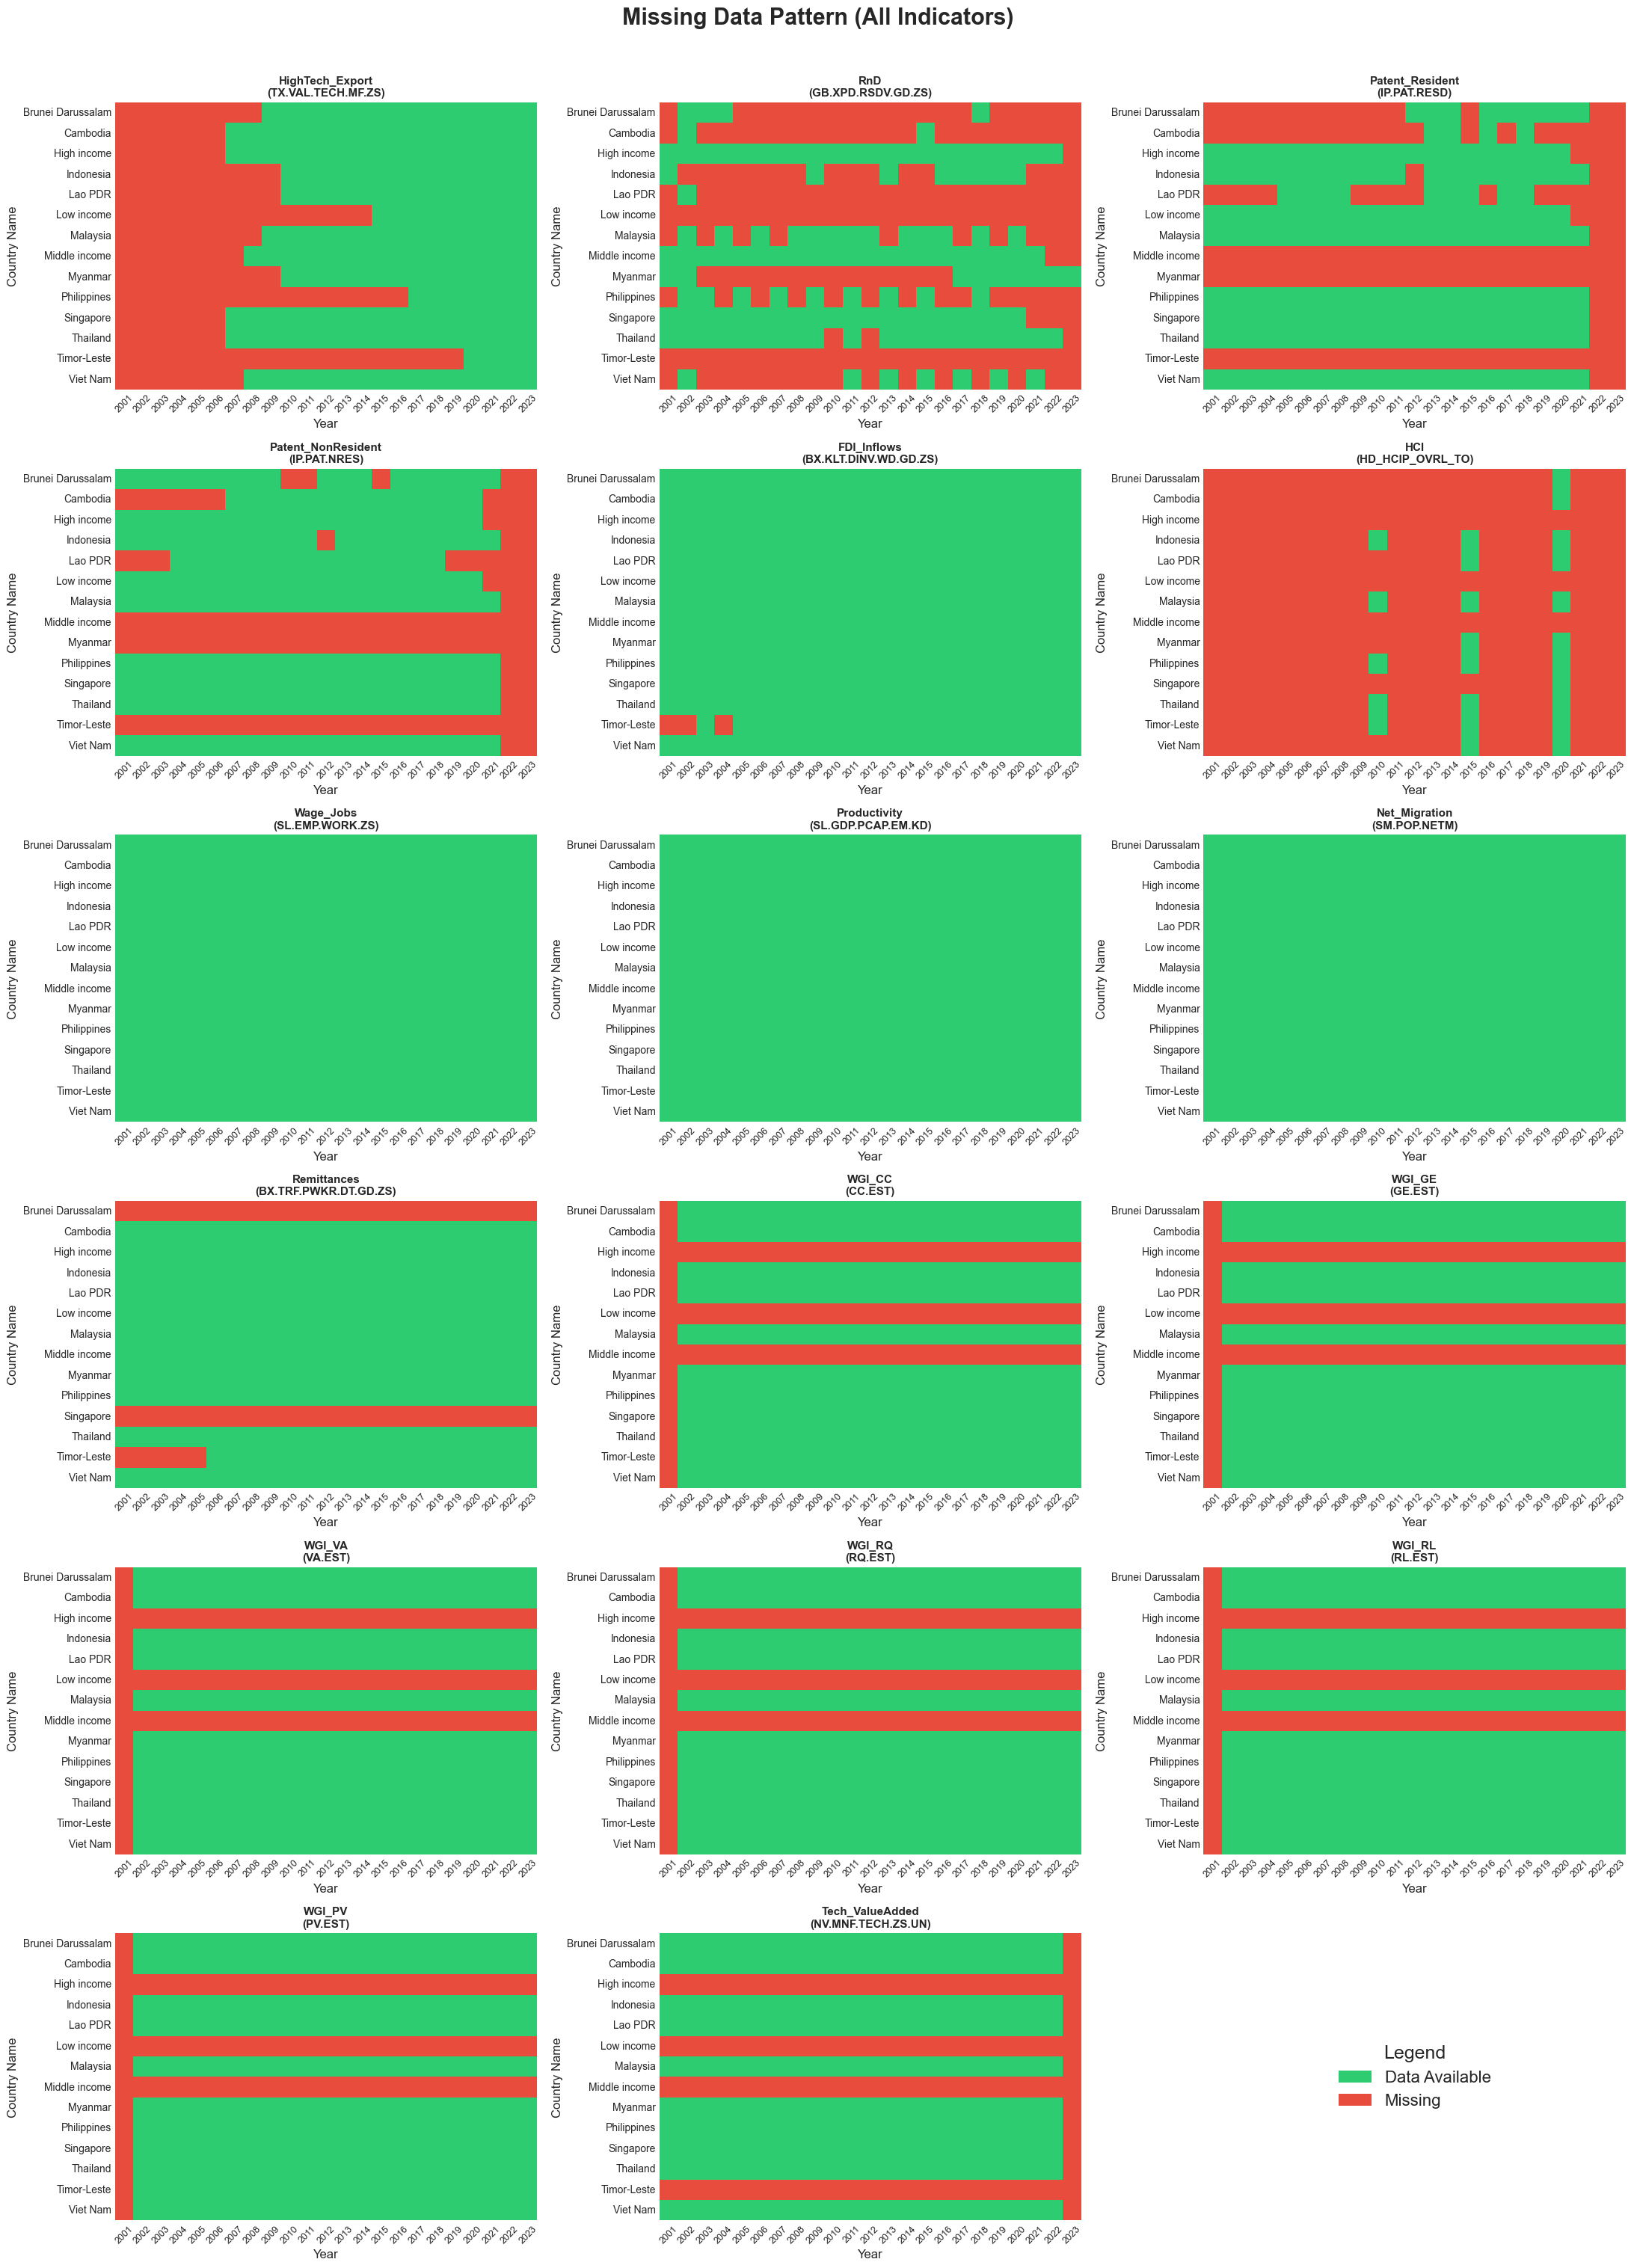

Chart saved: missing_data_pattern_all.pdf


In [3]:
# ===================== MISSING DATA HEATMAP (ALL INDICATORS) =====================
print('===== DRAW MISSING DATA HEATMAP FOR ALL INDICATORS =====')

# Get complete list of codes
plot_codes = list(indicators.keys())

# Configure layout 6 rows x 3 columns = 18 slots (17 indicators + 1 legend)
fig, axes = plt.subplots(6, 3, figsize=(22, 30))
axes = axes.flatten()

for idx, code in enumerate(plot_codes):
    ax = axes[idx]
    if code in data:
        # Get raw data (not filled missing) to see actual pattern
        df_plot = data[code].copy().set_index('Year')
        
        sns.heatmap(
            df_plot.isna().T,
            cbar=False,
            ax=ax,
            yticklabels=True,
            cmap=['#2ecc71', '#e74c3c']  # Green=Available, Red=Missing
        )
        ax.set_title(f"{indicators[code]}\n({code})", fontsize=11, weight='bold')
        ax.set_xlabel('Year')
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        ax.tick_params(axis='y', labelsize=10)
    else:
        # Case where variable is broken/cannot get data
        ax.axis('off')
        ax.text(0.5, 0.5, f"No data for:\n{indicators[code]}", 
                ha='center', va='center', fontsize=12, color='gray')

# Last slot (index 17) for Legend
ax_legend = axes[17]
ax_legend.axis('off')
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Data Available'),
    Patch(facecolor='#e74c3c', label='Missing')
]
ax_legend.legend(handles=legend_elements, loc='center', fontsize=16, 
                 title='Legend', title_fontsize=18)

plt.suptitle('Missing Data Pattern (All Indicators)', fontsize=22, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('missing_data_pattern_all.pdf', dpi=300, bbox_inches='tight')
plt.show()

print('Chart saved: missing_data_pattern_all.pdf')

# QUESTIONS

**Research Question:** To what extent does Vietnam's high-tech export-driven growth model reflect endogenous innovation capacity, as opposed to being primarily dependent on foreign direct investment (FDI)?

To answer the research question above, data is visualized through two main charts with variables defined as follows:

**A. Scatter Plot - Relationship between High-Tech Export and R&D Capacity:**
* **X-axis:** R&D Intensity (`RnD` - % of GDP) - Represents investment effort in research and development.
* **Y-axis:** High-Tech Export Share (`HighTech_Export` - % of total manufacturing exports) - Represents commercial output.
* **Bubble Size:** FDI Inflows (`FDI_Inflows`) - Represents the level of foreign enterprise intervention/contribution.
* **Color:** Dark red (Highlight) is used to emphasize Vietnam's position when compared with average levels of country groups by income level (Low, Middle, High).

**B. Horizontal Bar Chart - Patent Ownership Structure:**
* **Red Bar (`NonRes_Pct`):** Share of patents owned by foreign entities (Technology Dependency).
* **Blue-green Bar (`Res_Pct`):** Share of patents owned domestically (Domestic Control and Endogenous Innovation Capacity).

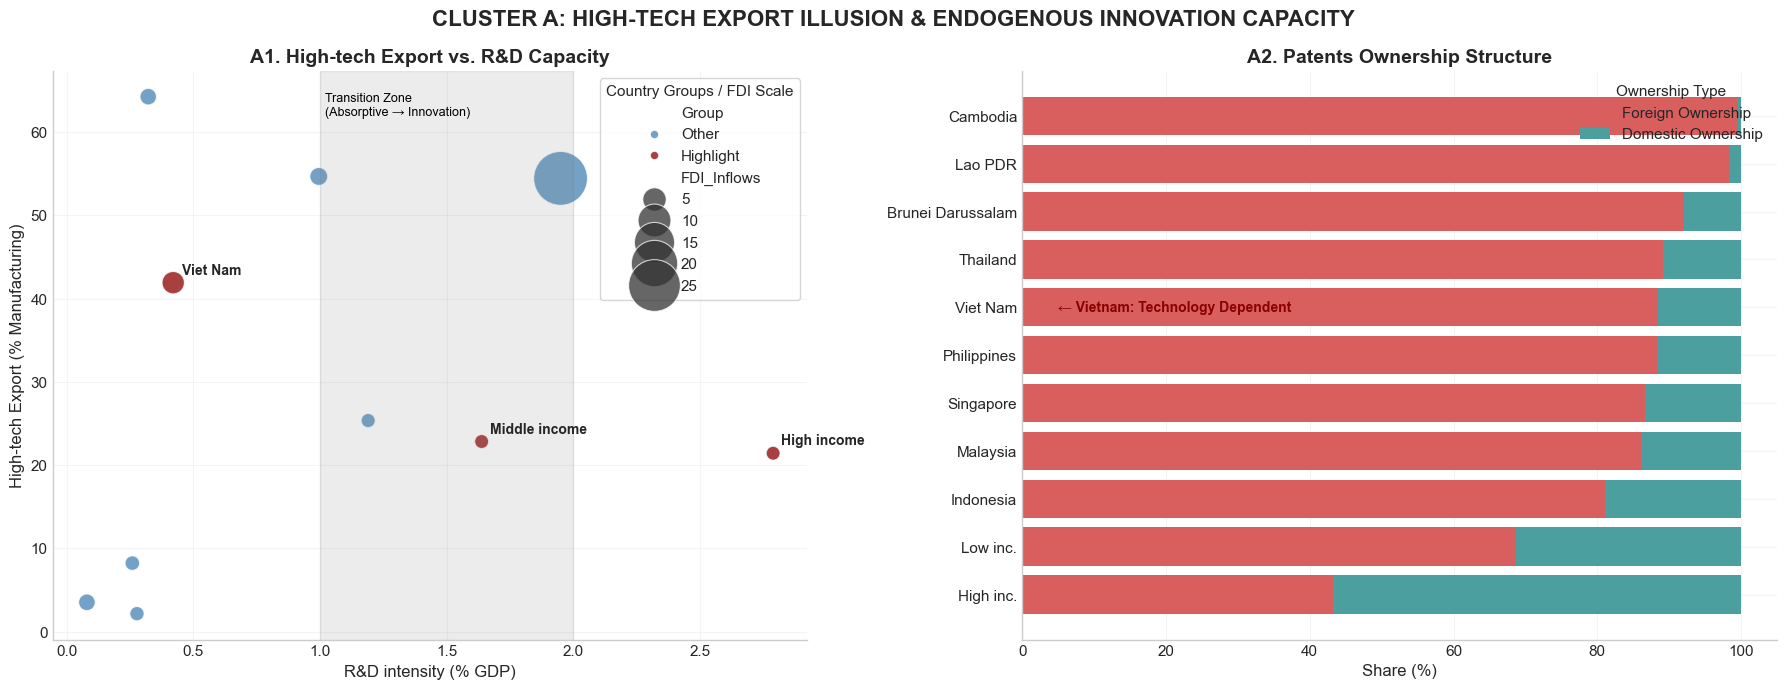

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('CLUSTER A: HIGH-TECH EXPORT ILLUSION & ENDOGENOUS INNOVATION CAPACITY',
             weight='bold', fontsize=16)

# ===================== A1: SCATTER =====================
df_a1 = (
    df_multi[df_multi['Year'] >= 2018]
    .groupby('Country Name')[['RnD', 'HighTech_Export', 'FDI_Inflows']]
    .mean()
    .reset_index()
    .dropna()
)

highlight = ['Viet Nam', 'Low income', 'High income', 'Middle income']

# Create color classification column
df_a1['Group'] = df_a1['Country Name'].apply(
    lambda x: 'Highlight' if x in highlight else 'Other'
)

palette = {'Highlight': 'darkred', 'Other': 'steelblue'}

scatter = sns.scatterplot(
    data=df_a1,
    x='RnD',
    y='HighTech_Export',
    size='FDI_Inflows',
    hue='Group',
    palette=palette,
    sizes=(100, 1500),
    alpha=0.75,
    ax=axes[0]
)

# Annotate highlight
for _, row in df_a1.iterrows():
    if row['Country Name'] in highlight:
        axes[0].annotate(
            row['Country Name'],
            (row['RnD'], row['HighTech_Export']),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=10,
            weight='bold'
        )

# ===== R&D TRANSITION ZONE (instead of "hard threshold") =====
axes[0].axvspan(1.0, 2.0, color='grey', alpha=0.15)

axes[0].text(
    1.02,
    axes[0].get_ylim()[1] * 0.92,
    'Transition Zone\n(Absorptive → Innovation)',
    fontsize=9,
    color='black'
)

axes[0].set_title('A1. High-tech Export vs. R&D Capacity', weight='bold')
axes[0].set_xlabel('R&D intensity (% GDP)')
axes[0].set_ylabel('High-tech Export (% Manufacturing)')


# Fix legend for scatter plot
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(
    handles=handles,
    labels=labels,
    title='Country Groups / FDI Scale',
    loc='upper right',
    frameon=True
)


# ===================== A2: BAR =====================
df_a2 = (
    df_multi[df_multi['Year'] >= 2018]
    .groupby('Country Name')[['Patent_Resident', 'Patent_NonResident']]
    .mean()
    .reset_index()
    .dropna()
)

df_a2['Total'] = df_a2['Patent_Resident'] + df_a2['Patent_NonResident']
df_a2['Res_Pct'] = df_a2['Patent_Resident'] / df_a2['Total'] * 100
df_a2['NonRes_Pct'] = df_a2['Patent_NonResident'] / df_a2['Total'] * 100

df_a2 = df_a2.sort_values('NonRes_Pct')

df_a2['Short_Name'] = df_a2['Country Name'].str.replace('income', 'inc.', regex=False)

# Bar chart
axes[1].barh(
    df_a2['Short_Name'],
    df_a2['NonRes_Pct'],
    color='#d95f5f',
    label='Foreign Ownership'
)
axes[1].barh(
    df_a2['Short_Name'],
    df_a2['Res_Pct'],
    left=df_a2['NonRes_Pct'],
    color='#4c9f9f',
    label='Domestic Ownership'
)

axes[1].set_title('A2. Patents Ownership Structure', weight='bold')
axes[1].set_xlabel('Share (%)')

# Highlight Vietnam
for i, name in enumerate(df_a2['Country Name']):
    if name == 'Viet Nam':
        axes[1].text(
            5, i,
            '← Vietnam: Technology Dependent',
            va='center',
            fontsize=10,
            weight='bold',
            color='darkred'
        )

axes[1].legend(title='Ownership Type', loc='upper right')


# ===================== FINAL TOUCH =====================
for ax in axes:
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

- Vietnam has an extremely high share of high-tech exports (far exceeding both Middle Income and High Income groups), yet its R&D intensity is at the lowest level and far from the transition zone. This reveals a massive gap between input and output—we are exporting things we have not created.
- The bubble size represents FDI Inflows, indicating Vietnam's role as a "processing and assembly factory" (capturing the lowest value-added portion in the supply chain), not as a technology-leading nation.
- Compared to high-income countries (where domestic ownership exceeds 50%) or even low-income countries (Low inc.—where domestic ownership accounts for about 30%), Vietnam is in a state of complete technological dependence. Not holding patents means the economy lacks "endogenous innovation capacity." If FDI inflows withdraw or shift to other countries, this export "illusion" will collapse instantly.

Is Vietnam effectively leveraging its human capital, or is it experiencing resource underutilization due to structural constraints in the labor market?

Cluster B uses two charts to demonstrate the "human capital paradox" with specific variables:

**B1. Scatter Plot - Training and Employment Paradox:**
* **X-axis:** Human Capital Index (`HCI`) - Represents the quality of labor force, education level, and health.
* **Y-axis:** Stable Wage Employment Rate (`Wage_Jobs`) - Represents the economy's capacity to provide high-quality, formal employment.
* **Dashed Lines:** Average level of the dataset. The intersection point divides the chart into 4 quadrants.

**B2. Bar Chart - Migration and Remittance Consequences:**
* **Red Bar (`Net_Migration_Scaled`):** Net Migration Rate. Negative values show more people leaving than entering (labor/brain drain).
* **Blue-green Bar (`Remittances`):** Remittances as % of GDP - Represents money sent home from exported workers.

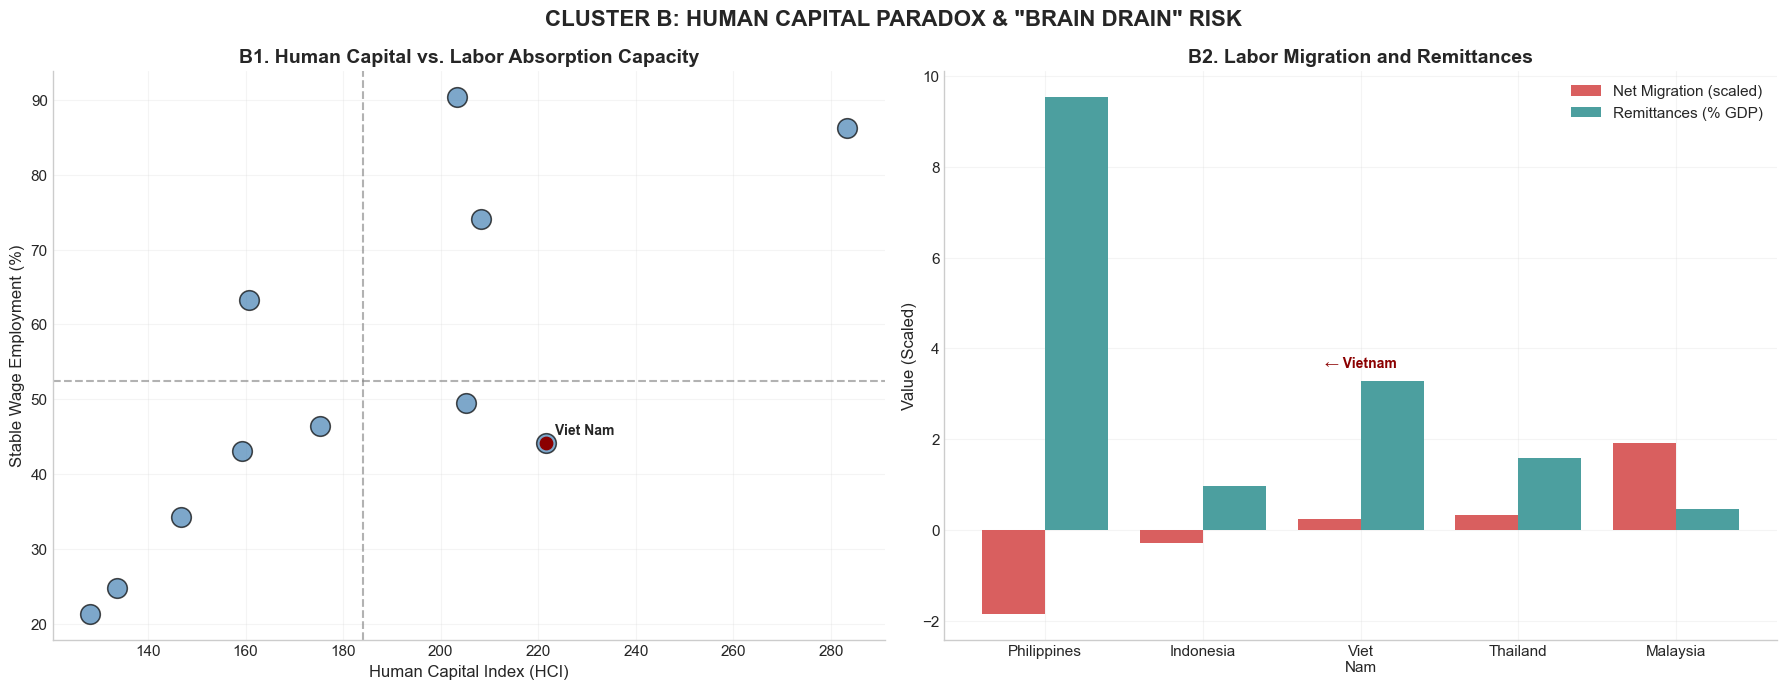

In [5]:
# ===================== PLOT: CLUSTER B =====================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('CLUSTER B: HUMAN CAPITAL PARADOX & "BRAIN DRAIN" RISK',
             weight='bold', fontsize=16)

# ===================== B1: SCATTER =====================
df_b1 = (
    df_multi[df_multi['Year'] == 2020]
    .dropna(subset=['HCI', 'Wage_Jobs'])
)

sns.scatterplot(
    data=df_b1,
    x='HCI',
    y='Wage_Jobs',
    color='steelblue',
    s=200,
    alpha=0.7,
    edgecolor='black',
    legend=False,
    ax=axes[0]
)

# Highlight like previous clusters
highlight = ['Viet Nam', 'Low income', 'High income', 'Middle income']

for _, row in df_b1.iterrows():
    if row['Country Name'] in highlight:
        axes[0].scatter(row['HCI'], row['Wage_Jobs'],
                        color='darkred', s=80, zorder=3)
        axes[0].annotate(
            row['Country Name'],
            (row['HCI'], row['Wage_Jobs']),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=10,
            weight='bold'
        )

# Mean lines (clean)
axes[0].axvline(df_b1['HCI'].mean(), color='gray', linestyle='--', alpha=0.6)
axes[0].axhline(df_b1['Wage_Jobs'].mean(), color='gray', linestyle='--', alpha=0.6)

axes[0].set_title('B1. Human Capital vs. Labor Absorption Capacity', weight='bold')
axes[0].set_xlabel('Human Capital Index (HCI)')
axes[0].set_ylabel('Stable Wage Employment (%)')


# ===================== B2: BAR (CLEAN) =====================
df_b2 = (
    df_multi[df_multi['Year'] >= 2015]
    .groupby('Country Name')[['Net_Migration', 'Remittances']]
    .mean()
    .reset_index()
    .dropna()
)

focus_mig = ['Philippines', 'Viet Nam', 'Indonesia', 'Thailand', 'Malaysia', 'Singapore']
df_b2 = df_b2[df_b2['Country Name'].isin(focus_mig)]

# Light scaling (avoid crowding)
df_b2['Net_Migration_Scaled'] = df_b2['Net_Migration'] / 100000

# Sort for clarity
df_b2 = df_b2.sort_values('Net_Migration_Scaled')

# Shorten names
df_b2['Short_Name'] = df_b2['Country Name'].str.replace(' ', '\n')

x = np.arange(len(df_b2))

axes[1].bar(
    x - 0.2,
    df_b2['Net_Migration_Scaled'],
    width=0.4,
    color='#d95f5f',
    label='Net Migration (scaled)'
)

axes[1].bar(
    x + 0.2,
    df_b2['Remittances'],
    width=0.4,
    color='#4c9f9f',
    label='Remittances (% GDP)'
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(df_b2['Short_Name'])

axes[1].set_title('B2. Labor Migration and Remittances', weight='bold')
axes[1].set_ylabel('Value (Scaled)')

# Highlight Vietnam
for i, name in enumerate(df_b2['Country Name']):
    if name == 'Viet Nam':
        axes[1].text(
            i,
            df_b2.iloc[i]['Remittances'] + 0.3,
            '← Vietnam',
            ha='center',
            fontsize=10,
            weight='bold',
            color='darkred'
        )

axes[1].legend(loc='upper right')


# ===================== FINAL TOUCH =====================
for ax in axes:
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

- There is a severe mismatch between Education and the Economy. The education system produces reasonably high-quality labor, but the domestic economy lacks sufficient capacity to absorb it. This aligns perfectly with Cluster A's hypothesis: an economy based mainly on contract manufacturing and assembly does not need (and does not have) many high-quality job positions for workers.
- The massive remittance inflows are the clearest evidence that the economy must solve unemployment/low-quality employment through labor and expert exports.
- Remittances are an excellent foreign exchange resource that helps stabilize social and macroeconomic stability in the short term. However, if we regard this as an achievement to be proud of, it represents an enormous risk. It shows we cannot retain our best talent. The country is "subsidizing" intelligence and youth to build economies for other nations, eliminating opportunities to develop endogenous innovation capacity.

**Research Question:** To what extent do current institutional constraints limit Vietnam's transition toward a knowledge-based growth model, and what are their broader impacts?

Cluster C uses two charts to evaluate the "software infrastructure" of the economy (institutions) with variables:

**C1. Radar Chart - Institutional Rails (WGI 2021):**
* Shows 6 Worldwide Governance Indicators (WGI). Values in the core (negative) indicate weak institutional quality; extending to the outer rim (positive) indicates strong institutions.
* **Dark Red Line:** Vietnam's actual scores compared across 6 axes (Control of Corruption, Government Effectiveness, Voice and Accountability, Regulatory Quality, Rule of Law, Political Stability). Gray lines are comparison groups (Singapore, Malaysia, High Income).

**C2. Scatter Plot - Rule of Law and Core Technology Capacity:**
* **X-axis:** Rule of Law Index (`WGI_RL` from -2.5 to 2.5) - Represents fairness, protection of property rights, and contracts.
* **Y-axis:** Technology Value Added (`Tech_ValueAdded` - %) - Represents capacity to create core technological capabilities.
* **Red Dashed Line:** The 0 threshold for Rule of Law, boundary between weak legal systems (left) and stable ones (right).

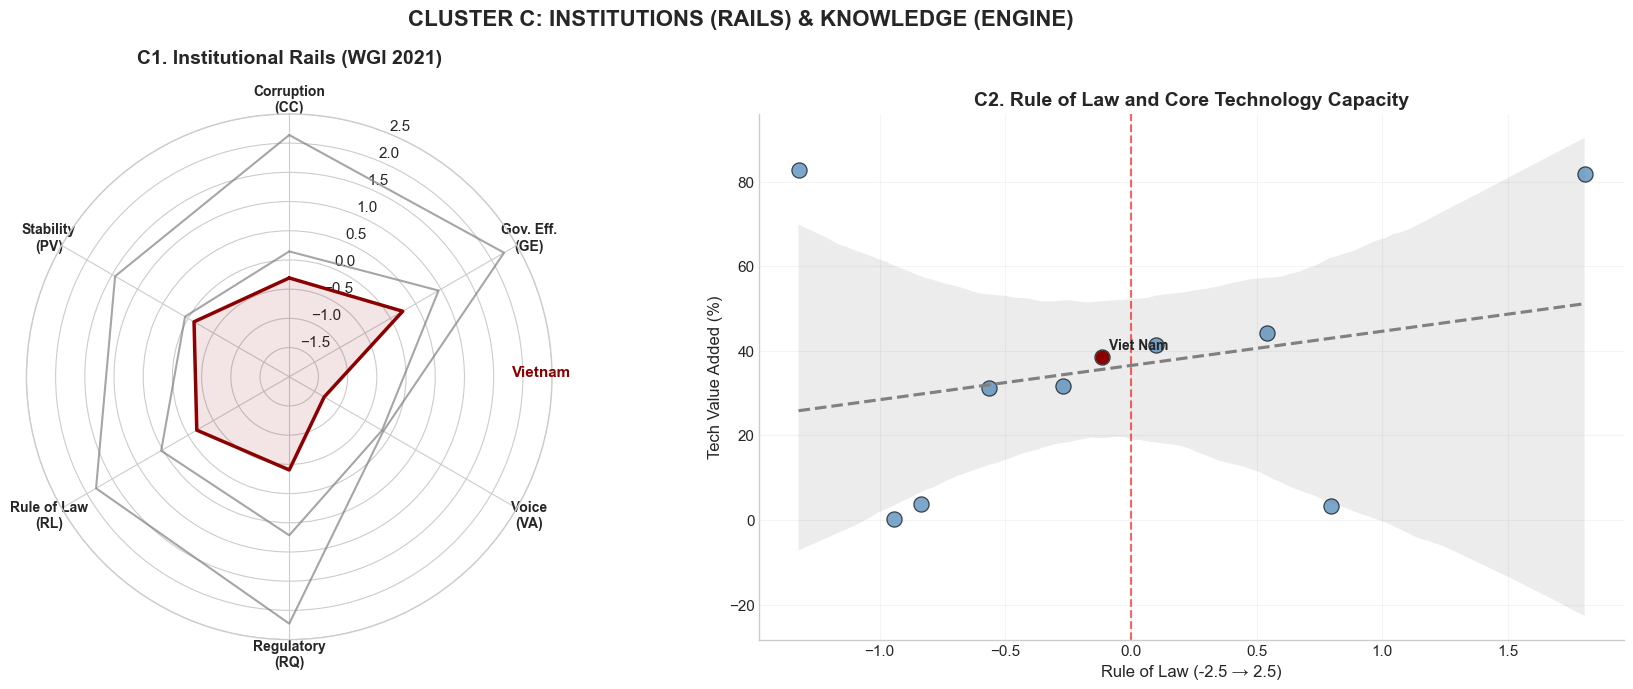

In [6]:

fig = plt.figure(figsize=(18, 7))
fig.suptitle('CLUSTER C: INSTITUTIONS (RAILS) & KNOWLEDGE (ENGINE)',
             weight='bold', fontsize=16)

# ===================== C1: RADAR =====================
ax_radar = fig.add_subplot(1, 2, 1, polar=True)

wgi_cols = ['WGI_CC', 'WGI_GE', 'WGI_VA', 'WGI_RQ', 'WGI_RL', 'WGI_PV']
wgi_labels = [
    'Corruption\n(CC)', 'Gov. Eff.\n(GE)', 'Voice\n(VA)',
    'Regulatory\n(RQ)', 'Rule of Law\n(RL)', 'Stability\n(PV)'
]

df_c1 = df_multi[df_multi['Year'] == 2021].dropna(subset=wgi_cols)

# Focus on key groups like previous clusters
focus_rad = ['Viet Nam', 'Singapore', 'Malaysia', 'High income']

angles = np.linspace(0, 2*np.pi, len(wgi_cols), endpoint=False).tolist()
angles += angles[:1]

ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(wgi_labels, fontsize=10, weight='bold')
ax_radar.set_ylim(-2, 2.5)

for c in focus_rad:
    if c in df_c1['Country Name'].values:
        vals = df_c1[df_c1['Country Name'] == c][wgi_cols].values.flatten().tolist()
        vals += vals[:1]

        # Highlight Vietnam like previous styles
        if c == 'Viet Nam':
            ax_radar.plot(angles, vals, color='darkred', linewidth=2.5)
            ax_radar.fill(angles, vals, color='darkred', alpha=0.1)
        else:
            ax_radar.plot(angles, vals, color='gray', linewidth=1.5, alpha=0.7)

ax_radar.set_title('C1. Institutional Rails (WGI 2021)', weight='bold', y=1.08)

# Remove legend for cleanliness (like A, B)
ax_radar.text(np.pi/2, 2.3, 'Vietnam', color='darkred', ha='center', weight='bold')


# ===================== C2: SCATTER =====================
ax_scatter = fig.add_subplot(1, 2, 2)

df_c2 = (
    df_multi[df_multi['Year'] >= 2018]
    .groupby('Country Name')[['WGI_RL', 'Tech_ValueAdded']]
    .mean()
    .reset_index()
    .dropna()
)

# Light regression line
sns.regplot(
    data=df_c2,
    x='WGI_RL',
    y='Tech_ValueAdded',
    scatter=False,
    color='gray',
    line_kws={"linestyle": "--"},
    ax=ax_scatter
)

# Clean scatter (no hue)
sns.scatterplot(
    data=df_c2,
    x='WGI_RL',
    y='Tech_ValueAdded',
    color='steelblue',
    s=120,
    alpha=0.7,
    edgecolor='black',
    ax=ax_scatter
)

# Highlight like other clusters
highlight = ['Viet Nam', 'High income', 'Middle income', 'Low income']

for _, row in df_c2.iterrows():
    if row['Country Name'] in highlight:
        ax_scatter.scatter(row['WGI_RL'], row['Tech_ValueAdded'],
                           color='darkred', s=80, zorder=3)
        ax_scatter.annotate(
            row['Country Name'],
            (row['WGI_RL'], row['Tech_ValueAdded']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=10,
            weight='bold'
        )

# Threshold line (maintain narrative)
ax_scatter.axvline(0, color='red', linestyle='--', alpha=0.6)

ax_scatter.set_title('C2. Rule of Law and Core Technology Capacity', weight='bold')
ax_scatter.set_xlabel('Rule of Law (-2.5 → 2.5)')
ax_scatter.set_ylabel('Tech Value Added (%)')


# ===================== FINAL TOUCH =====================
for ax in [ax_scatter]:
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

- Compared to the expanded gray rails (typically representing developed countries or regional leaders), Vietnam's institutions reveal comprehensive weaknesses. Especially, foundational elements for nurturing innovation—like Regulatory Quality, Voice, and Rule of Law—all fall short of global averages. Such "narrow rails" make it very difficult for the "knowledge engine" to run smoothly at high speed.
- Weak rule of law (not exceeding the 0 threshold) is the "bottleneck." When intellectual property rights, contract risks, and legal certainty are not firmly secured, businesses (both domestic and FDI) will not dare invest heavily in R&D or transfer core technology.
- If we link Cluster C with common economic problems (like FDI-dependent exports or brain drain), we can see the root cause lies here. Without a solid legal framework and good government quality (C1, C2), a country will only attract low-level contract manufacturing, not create value-added from core technology with endogenous innovation character.